# CS229 Simplified PS1 — Regression Experiments

参考 CS229 feature maps、gradient descent 与 LWR 作业题型。

这不是 Stanford 官方作业副本，而是用于自学的**简化原创版本**。题型参考公开的
CS229 problem sets；公式以 2026 Main Notes 为准，数据由本仓库确定性生成。

- [Spring 2026 课程主页](https://cs229.stanford.edu/index.html-spr26)
- [Spring 2026 公开视频](https://www.youtube.com/playlist?list=PLaqpC4kq8Gpw)
- [CS229 2026 Main Notes](https://cs229.stanford.edu/main_notes.pdf)
- [Stanford 官方公开的 Summer 2020 problem sets](https://cs229.stanford.edu/summer2020/)
- [公开可见的 Summer 2025 作业结构参考](https://github.com/MDzimah/Stanford-University-CS229-Machine-Learning)

**使用规则：** 先手推，再写代码。不要先看学生 solution。每道题完成后才把对应的
`RUN_*_CHECKS` 改成 `True`。检查不通过时，从 shape 和公式开始定位。

**怎么读题：** `m` 表示样本数，`d` 表示设计矩阵的列数（含截距列时也计入）。
`X` 的每一行是一条样本，`y[i]` 是对应目标；`(m,)` 是一维数组，和 `(m, 1)` 不同。
“实现”指填写函数中的 TODO；“运行检查”指执行已经给出的调用代码；“解释”写在答题框中。
函数定义格和检查格需要分别运行。检查通过只代表已检查的条件成立，不代替解释实验结果。

## Goal

从同一份回归数据出发，练习最小二乘的两种求解方法，再扩展模型：
P1 正规方程与 P2 梯度下降对应线性回归基础；P3 是在此基础上的多项式特征扩展，
不是要求你从 Lecture 2 中自行补出所有概念；P4 使用局部加权回归。

## Setup

每行数据是一对 `(x_i, y_i)`：`x_i` 是一个数，`y_i` 是要预测的连续值。
`x_train` 与 `y_train` 都为 `(60,)`；验证集和测试集各 40 条。

- **train（训练集）：** 只用这部分数据估计模型参数 `theta`。
- **valid（验证集）：** 把训练好的模型拿来预测，比较 degree 或 tau 等设置，不在这里重新拟合。
- **test（测试集）：** 留待模型选择结束后的最终评估；本题集不要求使用它。

先运行数据格观察训练散点。P1 提供的 `mse` 会在 P2–P4 复用；P3 不依赖 P2，
P4 复用 P1 的 `add_intercept` 和 `mse`。从头执行函数定义后，再打开已完成题目的检查开关。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(229)

candidates = [Path("data"), Path("problem_sets/ps1_regression/data")]
DATA_DIR = next((path for path in candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Run: python scripts/build_problem_sets.py")

print("Data directory:", DATA_DIR.resolve())


Data directory: /Users/yuanye/Projects/cs229/problem_sets/ps1_regression/data


### 加载并查看本题集的数据

上格准备了库和数据目录。下格读取数据、打印 shape，并展示实验输入；按顺序运行即可。

train: (60,) (60,)
valid: (40,) (40,)
test : (40,) (40,)


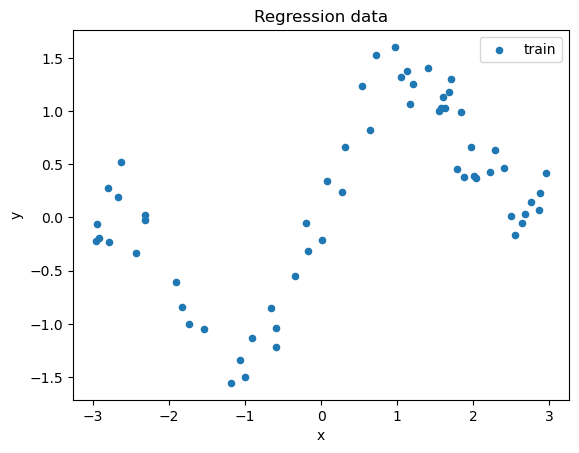

In [2]:
def load_xy(filename):
    data = np.loadtxt(DATA_DIR / filename, delimiter=",", skiprows=1)
    return data[:, 0], data[:, 1]

x_train, y_train = load_xy("train.csv")
x_valid, y_valid = load_xy("valid.csv")
x_test, y_test = load_xy("test.csv")

print("train:", x_train.shape, y_train.shape)
print("valid:", x_valid.shape, y_valid.shape)
print("test :", x_test.shape, y_test.shape)

plt.scatter(x_train, y_train, s=20, label="train")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression data")
plt.legend()
plt.show()


## Problem 1 — Normal equation

**本题目的：** 从训练散点中找一条最合适的直线：求截距和斜率，再用验证集检查预测误差。你需要实现求参数和算 MSE 两个函数。

先在下方答题框从 $J(\theta)=\frac{1}{2m}\|X\theta-y\|^2$ 令梯度为零，推导关于 theta 的方程。

> **你的答案（请双击本格后填写）**
>
> TODO：写出从令梯度为零到 normal equation 的推导，并标注矩阵 shape。
损失函数为：

$$
J(\theta)=\frac{1}{2m}(X\theta-y)^T(X\theta-y)
$$

其中：

- $X\in\mathbb{R}^{m\times 2}$
- $\theta\in\mathbb{R}^{2}$
- $y\in\mathbb{R}^{m}$

对 $\theta$ 求梯度：

$$
\nabla_\theta J(\theta)
=
\frac{1}{m}X^T(X\theta-y)
$$

在损失函数的最小值处，梯度等于零：

$$
X^T(X\theta-y)=0
$$

展开：

$$
X^TX\theta-X^Ty=0
$$

因此：

$$
X^TX\theta=X^Ty
$$

程序需要求解的线性方程是：

$$
A\theta=b
$$

其中 $A=X^TX\in\mathbb{R}^{2\times2}$，
$b=X^Ty\in\mathbb{R}^{2}$，最终得到
$\theta\in\mathbb{R}^{2}$。

### 1. add_intercept

**已给出：** `add_intercept(x)` 为每个输入加一个常数 1，使截距也能参与矩阵乘法。
例如输入 `[2,3]`，返回 `[[1,2],[1,3]]`。
输入 `(m,)`，输出 `X:(m,2)`。每行的预测是 $\theta_0+\theta_1x_i$。
运行下格定义函数；不需要填写 TODO。

In [ ]:
def add_intercept(x):
    return np.column_stack([np.ones_like(x), x])


### 2. fit_normal_equation

**要写什么：** `fit_normal_equation(X, y)` 找到使训练平方误差最小的参数。
输入 `X:(m,d)`、`y:(m,)`；返回 `theta:(d,)`。

用上方推导得到的方程构造 `A` 和 `b`，再调用 `np.linalg.solve(A,b)`。
`solve` 的含义是求解 `A @ theta = b`，不要显式计算矩阵逆。
本题 `d=2`，但不要写死参数数量，P3 会用到更多列。
小例子：`X=[[1,0],[1,1]]`、`y=[1,3]`，应得到截距 1、斜率 2。

In [ ]:
def fit_normal_equation(X, y):
    # Fit theta without explicitly computing a matrix inverse.
    # START TODO
    A = X.T @ X
    b = X.T @ y
    theta = np.linalg.solve(A, b)
    return theta


**只检查刚才这个函数：** 填完并运行函数定义后，把下格 `TRY_FIT_NORMAL_EQUATION` 改为 `True`。
先用这个小例子核对输入输出，再继续下一步。

In [ ]:
TRY_FIT_NORMAL_EQUATION = False
if TRY_FIT_NORMAL_EQUATION:
    assert np.allclose(fit_normal_equation(np.array([[1., 0.], [1., 1.]]), np.array([1., 3.])), [1., 2.])
    print("fit_normal_equation: example passed")


### 3. 准备数据

先运行这格准备本题数据，后面的函数将使用它。

In [ ]:
# END TODO


### 4. mse

**要写什么：** `mse(y_true, y_pred)` 衡量预测平均错了多少。
两个输入都是 `(m,)`，返回一个数：先逐项相减，平方，再取平均。

$$\mathrm{MSE}=\frac1m\sum_i(y_i-\hat y_i)^2.$$

例如真实值 `[1,3]`、预测 `[2,3]`，平方误差为 `[1,0]`，MSE 应为 `0.5`。
它是损失 $J$ 的两倍；两者的最小值出现在同一组参数处。

In [ ]:
def mse(y_true, y_pred):
    # START TODO
    return np.mean((y_true - y_pred) ** 2)


**只检查刚才这个函数：** 填完并运行函数定义后，把下格 `TRY_MSE` 改为 `True`。
先用这个小例子核对输入输出，再继续下一步。

In [ ]:
TRY_MSE = False
if TRY_MSE:
    assert np.isclose(mse(np.array([1., 3.]), np.array([2., 3.])), 0.5)
    print("mse: example passed")


### 5. 准备数据

先运行这格准备本题数据，后面的函数将使用它。

In [ ]:
# END TODO


### 6. 串起来：完整实验

训练 x → 加截距列 → 拟合 theta_ne → 用同一参数预测验证集 → 算 MSE。baseline 对所有验证样本都预测训练 y 的均值。

完成相关函数后，打开下格的 `RUN_P1_CHECKS` 并运行。

In [ ]:
RUN_P1_CHECKS = True
if RUN_P1_CHECKS:
    X_train = add_intercept(x_train)
    X_valid = add_intercept(x_valid)
    theta_ne = fit_normal_equation(X_train, y_train)
    valid_pred = X_valid @ theta_ne
    baseline = np.full_like(y_valid, y_train.mean())
    print("theta:", theta_ne)
    print("train MSE:", mse(y_train, X_train @ theta_ne))
    print("valid MSE:", mse(y_valid, valid_pred))
    print("baseline MSE:", mse(y_valid, baseline))
    assert theta_ne.shape == (2,)
    assert mse(y_valid, valid_pred) < mse(y_valid, baseline)
else:
    print("P1 checks are off.")


## Problem 2 — Gradient descent

**本题目的：** 用很多次小步更新，再求一遍 Problem 1 的最佳直线，检查结果是否与正规方程接近。请先运行 P1 的完整实验，得到 theta_ne。

> **你的答案（请双击本格后填写）**
>
> TODO：写出一次 gradient-descent update，包括学习率。
$$
\theta = (X^TX)^{-1}(X^T)y
$$

$$
\nabla_\theta J(\theta)
=
\frac{1}{m}X^T(X\theta-y)
$$

$$
\theta \leftarrow \theta - \alpha \nabla_\theta J(\theta)
$$

### 1. fit_gradient_descent

**要写什么：** `fit_gradient_descent` 从全零参数开始，反复计算梯度并更新。
`X:(m,d)`、`y:(m,)`；返回最终参数 `(d,)` 与记录 MSE 的一维 `history`。
`learning_rate` 是步长，`steps` 是参数更新次数。

循环里按顺序处理：预测 `(m,)` → 误差 `(m,)` → 梯度 `(d,)` → 更新参数。
`history` 只存一个个 MSE 数字，不参与求梯度。具体更新式写在上方答题框。

本题按已有约定，每 10 次更新记录一次**更新前**的预测 MSE。
`step % 10 == 0` 对应 0、10、20……，不是只更新这些步。
1000 次更新会留下 100 个记录点。保留相同约定，后面画图的横轴才一致。

In [30]:
def fit_gradient_descent(X, y, learning_rate=0.05, steps=1000):
    theta = np.zeros(X.shape[1])
    history = []
    for step in range(steps):
        # START TODO
        predictions = X @ theta
        errors = predictions - y
        gradient = (X.T @ errors) / len(y)
        theta -= learning_rate * gradient
        if step % 10 == 0:
            loss = mse(y, predictions)
            history.append(loss)
        # END TODO
    return theta, np.array(history)


### 2. 串起来：完整实验

调用梯度下降 → 与 P1 的 theta_ne 比较 → 画训练 MSE。每 10 步记录一次，所以记录下标 0、1、2 对应 step 0、10、20；横轴乘 10 是为恢复真实迭代编号。MSE 下降趋稳即可，不要求降到 0。

完成相关函数后，打开下格的 `RUN_P2_CHECKS` 并运行。

In [ ]:
RUN_P2_CHECKS = True
if RUN_P2_CHECKS:
    theta_gd, history = fit_gradient_descent(add_intercept(x_train), y_train)
    print("GD theta:", theta_gd)
    print("normal-equation theta:", theta_ne)
    assert len(history) > 1 and history[-1] < history[0]
    assert np.allclose(theta_gd, theta_ne, atol=0.1)
    plt.plot(np.arange(len(history)) * 10, history)
    plt.xlabel("step")
    plt.ylabel("training MSE")
    plt.title("Gradient-descent learning curve")
    plt.show()
else:
    print("P2 checks are off. Run P1 first, then complete P2.")


## Problem 3 — Polynomial feature map

**本题目的：** 让模型能拟合弯曲的数据。你只需要实现 polynomial_features；后面会先用三次模型逐步演示，再比较 1、3、10 次模型。先运行 P1，复用求参数和算 MSE 的函数。

### 1. polynomial_features

**要写什么：** `polynomial_features(x, degree)` 将每个数展开成一行多项式特征。
`degree` 是最高次数，例如 `degree=3` 表示计算到三次方。

输入 `x=np.array([2.,3.])`、`degree=3`，应输出：

```text
[[1., 2., 4.,  8.],
 [1., 3., 9., 27.]]
```

每行依次是 `[1,x,x²,x³]`。第一列是全 1，表示截距。
输入 shape 为 `(m,)`，输出为 `(m,degree+1)`；输出矩阵通常记为 `Phi`，读作 phi。
**这一步只转换输入，不使用 y，也不求 theta。** 不需要再调用 `add_intercept`。

实现提示：依次算 `x**0` 到 `x**degree`，把得到的各列用 `np.column_stack` 并排放好。
下格保留 TODO，填写你自己的实现，再运行这个函数定义格。

In [ ]:
def polynomial_features(x, degree):
    # Return shape (m, degree + 1), including the intercept column.
    # START TODO
    raise NotImplementedError("Build powers 0 through degree")
    # END TODO


### 2. 用两个数检查函数

这一格只调用刚才的函数，不训练模型。填写函数后将 `RUN_P3_CHECKS` 改为 `True`；
本题后续各格都会使用这个开关。若小例子失败，先修函数，再往下运行。

In [ ]:
RUN_P3_CHECKS = False
if RUN_P3_CHECKS:
    example = polynomial_features(np.array([2., 3.]), 3)
    print(example)
    assert example.shape == (2, 4)
    assert np.allclose(example, [[1., 2., 4., 8.], [1., 3., 9., 27.]])


### 3. 转换训练集和验证集

先固定 `degree=3`，只做一个模型。`Phi_train` 就是转换后的训练输入，
`Phi_valid` 是转换后的验证输入；Phi 只是变量名里用来表示特征矩阵的词。

`x_train:(60,)` → `Phi_train:(60,4)`，`x_valid:(40,)` → `Phi_valid:(40,4)`。
每一行都是 `[1,x,x²,x³]`，`y_train`、`y_valid` 保持不变。
下格已经写好，运行后看看前三行和 shape。

In [ ]:
if RUN_P3_CHECKS:
    degree = 3
    Phi_train = polynomial_features(x_train, degree)
    Phi_valid = polynomial_features(x_valid, degree)
    print("Phi_train:", Phi_train.shape, "Phi_valid:", Phi_valid.shape)
    print("First three training rows:")
    print(Phi_train[:3])
    assert Phi_train.shape == (len(x_train), degree + 1)
    assert Phi_valid.shape == (len(x_valid), degree + 1)


### 4. 用训练数据拟合参数

复用 P1 写过的 `fit_normal_equation`，这次输入的矩阵有 4 列。
输出 `theta_poly:(4,)` 分别对应常数项、x、x²、x³ 的系数。

$$\hat y=\theta_0+\theta_1x+\theta_2x^2+\theta_3x^3.$$

只有这一步在求参数，输入必须使用训练集。验证集随后只用来预测和评价。

In [ ]:
if RUN_P3_CHECKS:
    theta_poly = fit_normal_equation(Phi_train, y_train)
    print("theta for degree=3:", theta_poly)
    assert theta_poly.shape == (degree + 1,)


### 5. 用同一组参数做预测

`Phi_train @ theta_poly` 给出训练集的 60 个预测；
`Phi_valid @ theta_poly` 给出验证集的 40 个预测。每一行特征和参数相乘，就得到一个预测值。

In [ ]:
if RUN_P3_CHECKS:
    train_prediction = Phi_train @ theta_poly
    valid_prediction = Phi_valid @ theta_poly
    print("prediction shapes:", train_prediction.shape, valid_prediction.shape)
    print("First five valid predictions:", valid_prediction[:5])


### 6. 计算两组预测误差

复用 P1 的 `mse`。训练 MSE 衡量已用于拟合的数据，验证 MSE 衡量未用于拟合的数据。
每次调用返回一个数；真实值与预测值必须来自同一批样本。

In [ ]:
if RUN_P3_CHECKS:
    train_mse = mse(y_train, train_prediction)
    valid_mse = mse(y_valid, valid_prediction)
    print("degree=3 train MSE:", train_mse)
    print("degree=3 valid MSE:", valid_mse)


### 7. 画出这一个模型的曲线

`grid` 是训练输入范围内的 400 个密集横坐标，用来把曲线画平滑。
先用同一个 degree 转换 grid，再用刚才训练的 theta_poly 预测。这里没有重新训练。
图的横轴是原始 x，纵轴是 y 或预测 y；这与 P2 的训练误差曲线不同。

In [ ]:
if RUN_P3_CHECKS:
    grid = np.linspace(x_train.min(), x_train.max(), 400)
    Phi_grid = polynomial_features(grid, degree)
    grid_prediction = Phi_grid @ theta_poly
    plt.figure(figsize=(9, 4))
    plt.scatter(x_train, y_train, s=15, color="black", alpha=0.5, label="train data")
    plt.plot(grid, grid_prediction, label="degree 3")
    plt.xlabel("x")
    plt.ylabel("y / predicted y")
    plt.legend()
    plt.title("One polynomial model: degree 3")
    plt.show()


### 8. 串起来：比较三个模型

下面把刚才的“转换 → 拟合 → 预测 → 评价 → 画图”放进一个循环，分别用 degree=1、3、10。
每个 degree 单独训练一组参数：1 次是直线，3 次有 4 个系数，10 次有 11 个系数。
三条线是三个模型的预测，不是分别画 x、x³、x¹⁰。

保留三行 MSE 输出和三条曲线，在下方答题框选出本次验证 MSE 最低的 degree。
训练、验证误差都高且错过明显趋势，支持欠拟合判断；训练更好、验证反而变差，
才支持过拟合判断。不要预先认定 10 次一定过拟合。
高次多项式也可能有数值问题，求解报错不直接等于过拟合。

In [ ]:
if RUN_P3_CHECKS:
    example = polynomial_features(np.array([2., 3.]), 2)
    assert example.shape == (2, 3)
    assert np.allclose(example, [[1., 2., 4.], [1., 3., 9.]])
    grid = np.linspace(x_train.min(), x_train.max(), 400)
    plt.figure(figsize=(9, 4))
    for degree in (1, 3, 10):
        Phi_train = polynomial_features(x_train, degree)
        Phi_valid = polynomial_features(x_valid, degree)
        assert Phi_train.shape == (len(x_train), degree + 1)
        assert Phi_valid.shape == (len(x_valid), degree + 1)
        theta_poly = fit_normal_equation(Phi_train, y_train)
        train_mse = mse(y_train, Phi_train @ theta_poly)
        valid_mse = mse(y_valid, Phi_valid @ theta_poly)
        print(f"degree={degree:2d} train={train_mse:.4f} valid={valid_mse:.4f}")
        plt.plot(grid, polynomial_features(grid, degree) @ theta_poly, label=f"degree {degree}")
    plt.scatter(x_train, y_train, s=15, color="black", alpha=0.5, label="train data")
    plt.xlabel("x")
    plt.ylabel("y / predicted y")
    plt.legend()
    plt.title("Polynomial regression")
    plt.show()
else:
    print("P3 checks are off. Complete P1 first.")


> **你的答案（请双击本格后填写）**
>
> TODO：列出三个 degree 的 train/valid MSE，选择验证 MSE 最低者；结合曲线说明欠拟合或过拟合的证据，证据不足也请说明。

## Problem 4 — Locally weighted regression

**本题目的：** 预测一个位置时，让附近的训练样本更有影响。为每个查询位置拟合一条局部直线，比较不同邻域宽度 tau 的预测效果。复用 P1 的 add_intercept 和 mse。

### 1. predict_lwr

**要写什么：** `predict_lwr(x_train,y_train,x_query,tau)` 为每个查询位置预测一个值。
训练输入、目标都为 `(m,)`，查询位置为 `(n,)`，返回预测 `(n,)`。
`tau>0` 控制邻域宽度：较小的 tau 让远处训练点的影响更小。

对 `x_query` 中的每个 `q`，按下面四步组织函数：

1. 用 P1 的 `add_intercept(x_train)` 构造 `X:(m,2)`。
2. 计算权重 $w_i(q)=\exp(-(x_i-q)^2/(2\tau^2))$，将它们放进对角矩阵 `W`。
3. 从 $J_q(\theta)=\frac12\sum_i w_i(q)(X_i\theta-y_i)^2$ 推导加权正规方程，
   用 `np.linalg.solve` 求这一个 `q` 的局部参数 `(2,)`。
4. 用 `[1,q]` 与局部参数算一个预测，按顺序存入输出；换下一个 `q` 重新算权重和参数。

例如传入 `x_query=[0.,1.]` 时应返回两个预测值，而非两组参数。
查询位置不需要真实标签；所有拟合都只使用训练集。

In [ ]:
def predict_lwr(x_train, y_train, x_query, tau):
    # Return one LWR prediction per query point.
    # START TODO
    raise NotImplementedError("Compute weights and solve one local model per query")
    # END TODO


### 2. 串起来：完整实验

分别用 tau=0.1、0.5、2.0 预测验证集并比较 MSE，再预测密集 grid 画曲线。grid 只是画图用的位置，不参与训练。最后在答题框写加权方程和你的选择。

完成相关函数后，打开下格的 `RUN_P4_CHECKS` 并运行。

In [ ]:
RUN_P4_CHECKS = False
if RUN_P4_CHECKS:
    grid = np.linspace(x_train.min(), x_train.max(), 300)
    for tau in (0.1, 0.5, 2.0):
        valid_pred = predict_lwr(x_train, y_train, x_valid, tau)
        print(f"tau={tau:.1f} valid MSE={mse(y_valid, valid_pred):.4f}")
        plt.plot(grid, predict_lwr(x_train, y_train, grid, tau), label=f"tau={tau}")
    plt.scatter(x_train, y_train, s=15, color="black", alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("y / predicted y")
    plt.legend()
    plt.title("Locally weighted regression")
    plt.show()
else:
    print("P4 checks are off.")


> **你的答案（请双击本格后填写）**
>
> TODO：写出加权正规方程；列出各 tau 的 valid MSE 和选择。结合曲线解释小邻域对局部噪声的敏感性，以及大邻域可能遗漏的变化。

## Checks

- [ ] 所有设计矩阵的第一列都是 1。
- [ ] 没有显式计算矩阵逆；使用 `np.linalg.solve`。
- [ ] gradient descent 与 normal equation 得到接近的参数。
- [ ] 对 polynomial degree 和 LWR tau 的判断来自验证集，不来自测试集。

## Next Steps

完成 PS1 后再进入分类；不要提前使用分类指标解释回归模型。